## Params recommended
  *   Word embedding: (One-hot encoding,FastText), (GloVe(300), Word2Vec is not for char based)
  *   Learning rate (alpha): 0.001
  *   Dropout: 0.2 ~ 0.5
  *   Epoch for word learning: 5 ~ 50
  *   Epoch for dataset: 10 ~ 100
  *   Activation function: ReLU (Rectified Linear Unit), Sigmoid
  *   Error function (Loss function):
    *   Mean Squared Error (MSE)
    *   Cross Entropy Loss
    *   Binary Cross-Entropy
  *   Type of GD (Gradient Descent):
    *   Stochastic (batch=1),
    *   Batch
    *   Mini-batch (batch_size=32, 64):
  *   Optimizers:
    *   Adam
    *   RMSProp
  *   Model:
    *   LSTM,
    *   BiLSTM
    *   Transformer encoder (because order of characters matters)


## Used params
*   Word embedding: One-hot encoding
*   Learning rate (alpha): 0.001
*   Dropout: 0.2 ~ 0.5
*   Epoch for word learning: 5 ~ 50
*   Epoch for dataset: 10 ~ 100
*   Activation function: ReLU (Rectified Linear Unit), Sigmoid
*   Error function (Loss function):
   *   Mean Squared Error (MSE)
   *   Cross Entropy Loss
   *   Binary Cross-Entropy
*   Type of GD (Gradient Descent):
   *   Stochastic (batch=1),
   *   Batch
   *   Mini-batch (batch_size=32, 64):
*   Optimizers:
   *   Adam
   *   RMSProp
*   Model:
	*   LSTM,
  *   BiLSTM
  *   Transformer encoder (because order of characters matters)



### Neural Net Architecture:
- Input layer size  = char_len × max_word_len
- Output layer size = same as input (autoencoder-like structure)
- Activation        = Sigmoid
- Loss              = Mean Squared Error (MSE)

Trainable Parameters:
- weight: shape = [input_dim, output_dim], random init
- bias: shape = [output_dim], random init

Training Hyperparameters:
- l_rate (learning rate)    → user-defined
- max_epoch (per word)      → user-defined
- error (MSE threshold)     → user-defined


Transformers version: 4.56.1
Dataset namunalari:
                                tokens  \
0                 [a, ’, l, a, m, \n]   
1                    [a, ’, l, o, \n]   
2           [a, ’, l, o, c, h, i, \n]   
3  [a, ’, l, o, c, h, i, l, i, k, \n]   
4  [a, ’, l, o, h, a, z, r, a, t, \n]   

                                              labels  
0              [STEM, STEM, STEM, STEM, STEM, AFFIX]  
1                    [STEM, STEM, STEM, STEM, AFFIX]  
2  [STEM, STEM, STEM, STEM, AFFIX, AFFIX, AFFIX, ...  
3  [STEM, STEM, STEM, STEM, AFFIX, AFFIX, AFFIX, ...  
4  [STEM, STEM, STEM, STEM, STEM, STEM, STEM, STE...  


Map:   0%|          | 0/3969 [00:00<?, ? examples/s]

Map:   0%|          | 0/992 [00:00<?, ? examples/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at tahrirchi/tahrirchi-bert-small and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-71322237.py:140: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ulugbek0302 (ulugbek0302-urgench-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.248300,0.259260,0.884463,0.889530,0.884463,0.884864
2,0.196800,0.242116,0.904431,0.905501,0.904431,0.904620
3,0.156100,0.244382,0.906674,0.906611,0.906674,0.906553
4,0.118200,0.261272,0.913615,0.913869,0.913615,0.913689
5,0.095100,0.277877,0.912974,0.913083,0.912974,0.913014


Final Evaluation: {'eval_loss': 0.24211616814136505, 'eval_accuracy': 0.9044313934863855, 'eval_precision': 0.905501480598912, 'eval_recall': 0.9044313934863855, 'eval_f1': 0.9046195152632448, 'eval_runtime': 1.2004, 'eval_samples_per_second': 826.383, 'eval_steps_per_second': 51.649, 'epoch': 5.0}


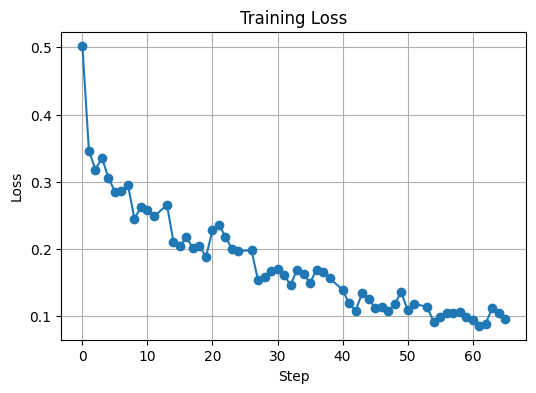

In [ ]:
# ============================
# 1. Installing dependencies
# ============================
# !pip install -U transformers datasets evaluate seqeval

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset, DatasetDict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
)

print("Transformers version:", transformers.__version__)

# ============================
# 2. Datasetni yuklash
# ============================
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Colab Notebooks/Prog/TrainData.txt"

data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip("")
        if not line:
            continue
        parts = line.split("/")
        if len(parts) == 2:
            stem, word = parts[0], parts[0]+parts[1]
            # stem = stem.replace("/", "")
            # word = word.replace("/", "")
            # Har bir belgiga STEM yoki AFFIX label beramiz
            labels = ["STEM"] * len(stem) + ["AFFIX"] * (len(word) - len(stem))
            data.append({"tokens": list(word), "labels": labels})

df = pd.DataFrame(data)
print("Dataset namunalari:\n", df.head())

# Train/test split
train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))
datasets = DatasetDict({"train": train_dataset, "test": test_dataset})

# ============================
# 3. Tokenizer
# ============================
model_name = "tahrirchi/tahrirchi-bert-small"
tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    use_fast=True,
    add_prefix_space=True  # RoBERTa oilasi uchun kerak
)

label_list = ["STEM", "AFFIX"]
label_to_id = {l: i for i, l in enumerate(label_list)}
id_to_label = {i: l for l, i in label_to_id.items()}

# ============================
# 4. Tokenizatsiya
# ============================
def tokenize_and_align_labels(example):
    # Matnga qaytarib yozamiz, chunki Roberta tokenizatsiya subword asosida bo‘ladi
    word = "".join(example["tokens"])
    tokenized = tokenizer(
        word,
        truncation=True,
        padding="max_length",
        max_length=32,
    )

    # Belgilarni tokenlarga map qilamiz
    labels = []
    for i in range(len(tokenized["input_ids"])):
        if i < len(example["labels"]):
            labels.append(label_to_id[example["labels"][i]])
        else:
            labels.append(-100)  # padding uchun
    tokenized["labels"] = labels
    return tokenized

encoded_datasets = datasets.map(tokenize_and_align_labels)

# ============================
# 5. Model va Training
# ============================
model = AutoModelForTokenClassification.from_pretrained(
    model_name, num_labels=len(label_list)
)

data_collator = DataCollatorForTokenClassification(tokenizer)

args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_strategy="steps",
    logging_steps=20,
    load_best_model_at_end=True,
)

# ============================
# 6. Metrics
# ============================
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=-1)

    true_labels, true_preds = [], []
    for pred, lab in zip(predictions, labels):
        for p_i, l_i in zip(pred, lab):
            if l_i != -100:
                true_labels.append(id_to_label[l_i])
                true_preds.append(id_to_label[p_i])

    report = classification_report(true_labels, true_preds, output_dict=True, zero_division=0)
    return {
        "accuracy": report["accuracy"],
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"],
        "f1": report["weighted avg"]["f1-score"],
    }

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=encoded_datasets["train"],
    eval_dataset=encoded_datasets["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# ============================
# 7. Train va Evaluate
# ============================
train_result = trainer.train()
eval_results = trainer.evaluate()
print("Final Evaluation:", eval_results)

# ============================
# 8. Loss curve
# ============================
logs = trainer.state.log_history
losses = [log["loss"] for log in logs if "loss" in log]
steps = [i for i, log in enumerate(logs) if "loss" in log]

plt.figure(figsize=(6,4))
plt.plot(steps, losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()
